# 01 - Exploratory Data Analyst
## Rossmann Store Sales Forecasting
Goal: understand the sales data, its trends and seasonality, and data quality issues, before doing any forecasting.
Specifically:
* Overall sales trend and seasonality (weekly, yearly)
* How much do individual stores vary?
* Confirm the known data quirks (StateHoliday type inconsistency, missing CompetitionDistance, closed-store days) and quantify them
* What's the effect of promotions and holidays on sales?

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load and merge data

In [2]:
train = pd.read_csv('../data/raw/train.csv', low_memory=False)
store = pd.read_csv('../data/raw/store.csv')

print('train shape:', train.shape)
print('store shape:', store.shape)

train shape: (1017209, 9)
store shape: (1115, 10)


In [3]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 2. Confirm the known data quirks
Don't assume the documentation is accurate for this specific copy of the data - verify each one directly.

In [4]:
print("StateHoliday unique values and types:")
print(train['StateHoliday'].apply(type).value_counts())
print(train['StateHoliday'].value_counts())

StateHoliday unique values and types:
StateHoliday
<class 'str'>    1017209
Name: count, dtype: int64
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


The `StateHoliday` column is a string data type, with the interesting quirk of having a '0' value with over 900,000 unique values

In [5]:
print("Missing values in store.csv:")
print(store.isnull().sum())
print("\nCompetitionDistance missing:", store["CompetitionDistance"].isnull().sum(),
      f"{store['CompetitionDistance'].isnull().mean()*100:.1f}%")

Missing values in store.csv:
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

CompetitionDistance missing: 3 0.3%


In [6]:
print('Rows where Open == 0 (closed):', (train['Open'] == 0).sum(),
      f'({(train['Open'] == 0).mean()*100:.1f}%)')
print('\nSales on closed days - should all be 0:')
print(train.loc[train['Open'] == 0, 'Sales'].describe())

Rows where Open == 0 (closed): 172817 (17.0%)

Sales on closed days - should all be 0:
count    172817.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64


There are only 3 rows with `CompetitionDistance` will missing values (~0.3% of total data missing) and we can confirm that there are no sales when stores are closed

## 3. Merge and do a full missing value check post merge

In [7]:
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "src"))
from preprocessing import clean_and_merge

train['Date'] = pd.to_datetime(train['Date'])
df = clean_and_merge(train, store)

print('Post-cleaning shape:', df.shape)
print('\nRemaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Post-cleaning shape: (844392, 18)

Remaining missing values:
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
dtype: int64


## 4. Overall sales trend over time
Aggregate across all stores first, to see the big picture before looking at individual store variation.

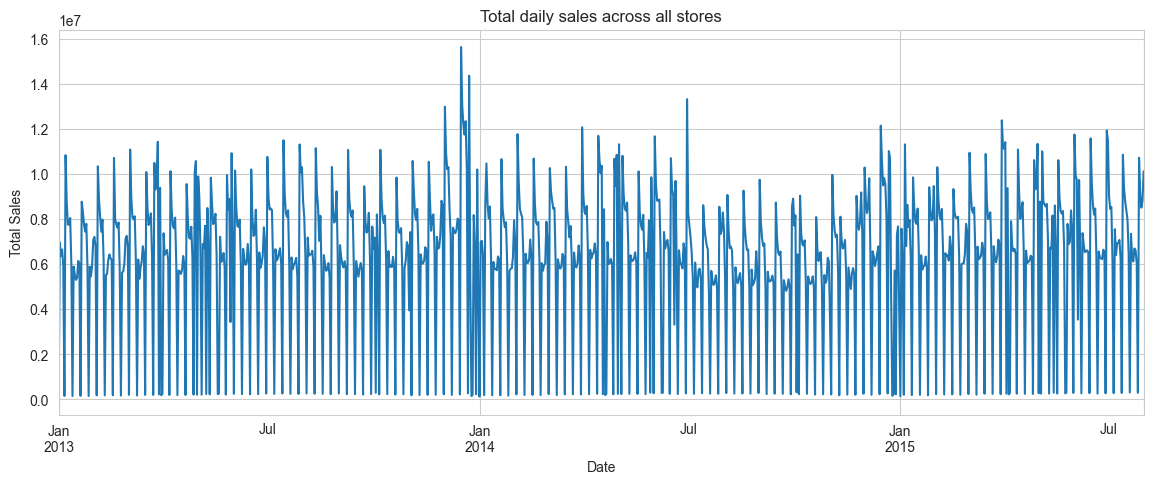

In [8]:
daily_total = df.groupby('Date')['Sales'].sum()
fig, ax = plt.subplots(figsize=(14, 5))
daily_total.plot(ax=ax)
ax.set_title('Total daily sales across all stores')
ax.set_ylabel('Total Sales')
plt.show()

The total sales across all stores seems relatively similar across the years; there's a slight increase in sales during holiday season 2013; however there are no gaps I can see visually (Rossmann data is known to have gap around July 2014 due to a data recording issue), so I will directly check to see if there are any gaps

In [17]:
date_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
missing_dates = date_range.difference(df['Date'].unique())
print(f'Missing dates in range: {len(missing_dates)}')
print(missing_dates[:20])

Missing dates in range: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


I've confirmed there are no missing dates in the date, it's likely the data recording issue was fixed at some point

## 5. Weekly seasonality
Retail sales usually vary a lot by day of week (weekends vs. weekdays) - worth confirming and quantifying before modeling.

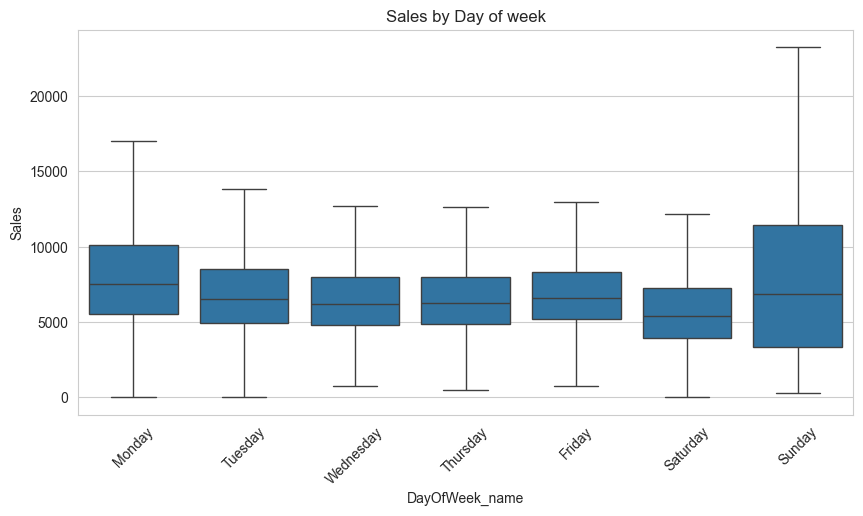

In [9]:
df['DayOfWeek_name'] = df['Date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig, ax = plt.subplots()
sns.boxplot(x='DayOfWeek_name', y='Sales', data=df, order=dow_order, ax=ax, showfliers=False)
ax.set_title('Sales by Day of week')
plt.xticks(rotation=45)
plt.show()

Sales seem highest on Mondays and Sundays and they dip between the days of Tuesday - Saturday. Its interesting that sales are low on Saturdays when people are more likely to shop. Sunday retailer closures are common in parts of Europe, so I want to see if the high Sunday sales might actually be driven by a small number of stores that *are* open on Sundays (e.g. novelty/tourist locations), rather than a genuine broad pattern.

In [15]:
print(df[df['DayOfWeek_name'] == 'Sunday']['Store'].nunique(), "unique stores selling on Sundays")
print(df['Store'].nunique(), "total unique stores")

33 unique stores selling on Sundays
1115 total unique stores


Out of all the 1115 unique stores, only 33 of them are open on Sundays, that means that this small subset of stores are open and do well on Sundays

## 6. Yearly/monthly seasonality

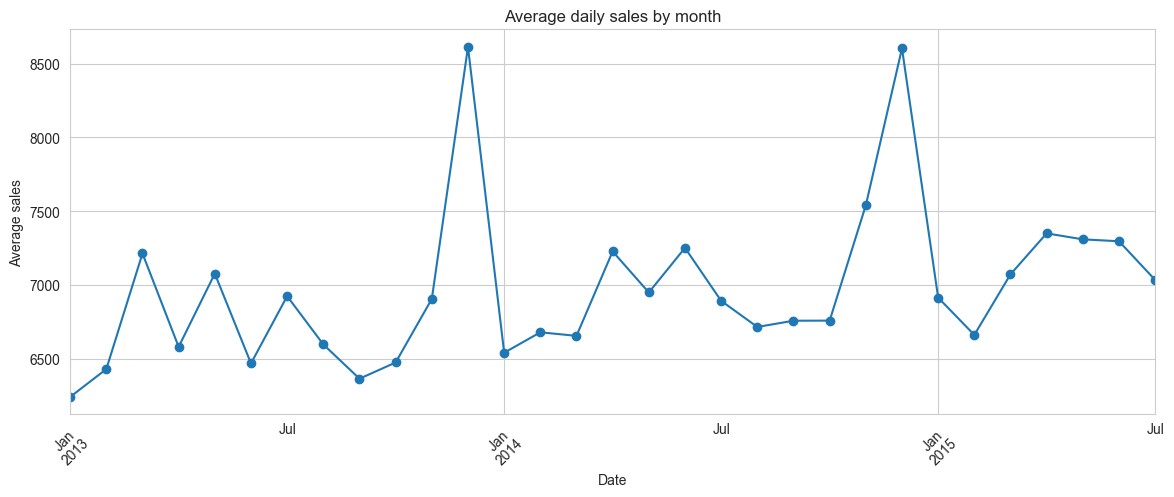

In [11]:
monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['Sales'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_avg.plot(ax=ax, marker='o')
ax.set_title('Average daily sales by month')
ax.set_ylabel('Average sales')
plt.xticks(rotation=45)
plt.show()

With around 2.5 years of data available, we see clear spikes in average sales around the holiday season in Decemeber of 2014 and 2015, sales then dip after the holiday season and raise a bit in the summer months

## 7. Effects of promotions

/var/folders/8h/x0jbyn051fs3cqqsc0yx7k600000gn/T/ipykernel_67145/2421879544.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No promo', 'Promo'])


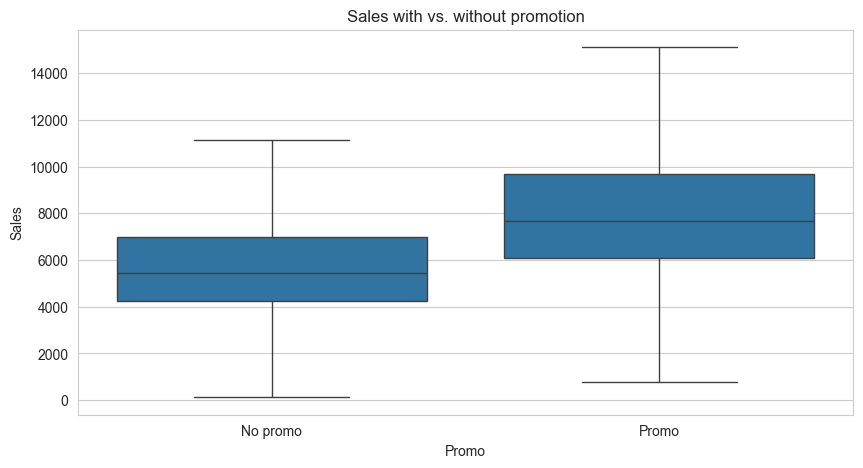

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64


In [12]:
fig, ax = plt.subplots()
sns.boxplot(x='Promo', y='Sales', data=df, ax=ax, showfliers=False)
ax.set_xticklabels(['No promo', 'Promo'])
ax.set_title('Sales with vs. without promotion')
plt.show()

print(df.groupby('Promo')['Sales'].mean())

There are more sales on average when there's a promotion; which makes sense

## 8. Per-store variation
Individual stores likely differ a lot in scale (a big-city flagship vs. a small-town one), worth understanding before deciding whether to model stores individually, in groups, or with store-level features capturing this variation.

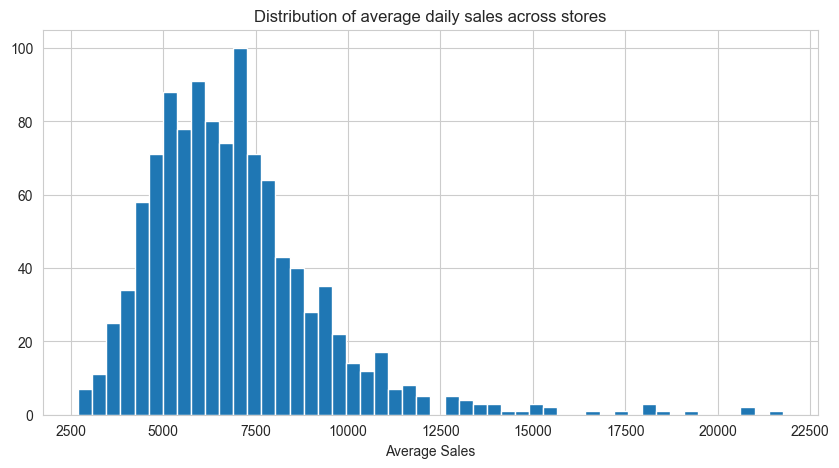

count     1115.000000
mean      6934.208449
std       2383.911051
min       2703.736573
25%       5322.299969
50%       6589.948470
75%       7964.200644
max      21757.483418
Name: Sales, dtype: float64


In [13]:
store_avg_sales = df.groupby('Store')['Sales'].mean().sort_values()

fig, ax = plt.subplots()
store_avg_sales.hist(bins=50, ax=ax)
ax.set_title('Distribution of average daily sales across stores')
ax.set_xlabel('Average Sales')
plt.show()

print(store_avg_sales.describe())

Average sales per store is around 6900 dollars, the distribution of sales per store skews left with a few stores with sales over 10,000 dollars (the max being around 21,000 dollars).

## 9. StoreType and Assortment effects

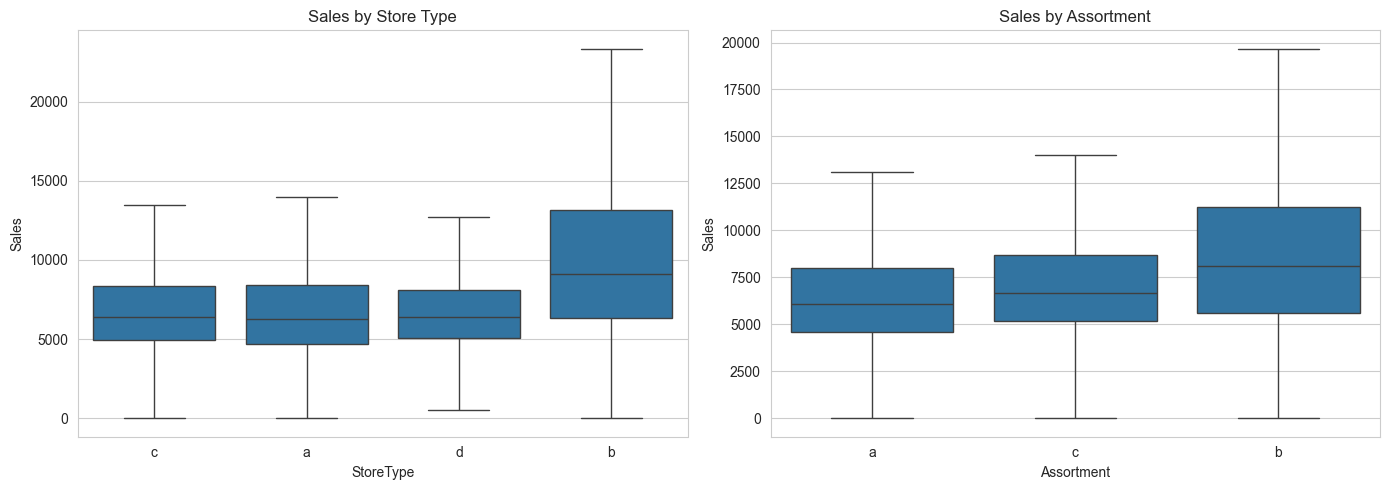

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='StoreType', y='Sales', data=df, ax=axes[0], showfliers=False)
axes[0].set_title('Sales by Store Type')
sns.boxplot(x='Assortment', y='Sales', data=df, ax=axes[1], showfliers=False)
axes[1].set_title('Sales by Assortment')
plt.tight_layout()
plt.show()

The type B stores and the Assortment b stores have the highest sales on average compared to other store types and assortment types

## 10. Summary of findings
* `StateHoliday` had the '0' type quirk that was expected
* There aren't any sales at stores when they are closed
* Stores see higher average sales on Mondays and during the holiday season in December
* There are a small subset of stores that are open on Sundays that have higher sales, but its not a big enough signal to include
* There are more sales when there are promotions
* Sales per store average around ~6900 dollars which a few stores having over ~10,000 in sales
* Store type B and assortment type B have higher average sales